<a href="https://colab.research.google.com/github/AI-Lab-2025-2-3rd/ai-project-codex/blob/emusigi/%E5%8E%9F%E6%9D%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 파일 불러오기 및 라이브러리 import

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from wordcloud import WordCloud

In [2]:
!git clone https://github.com/AI-Lab-2025-2-3rd/ai-project-codex.git

Cloning into 'ai-project-codex'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 52 (delta 16), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 4.36 MiB | 6.57 MiB/s, done.
Resolving deltas: 100% (16/16), done.


파일 위치 지정

In [3]:
file_path = './ai-project-codex/open/'

# 멘션 아이디 제거 시각화

@ 텍스트 추출 (멘션 아이디)



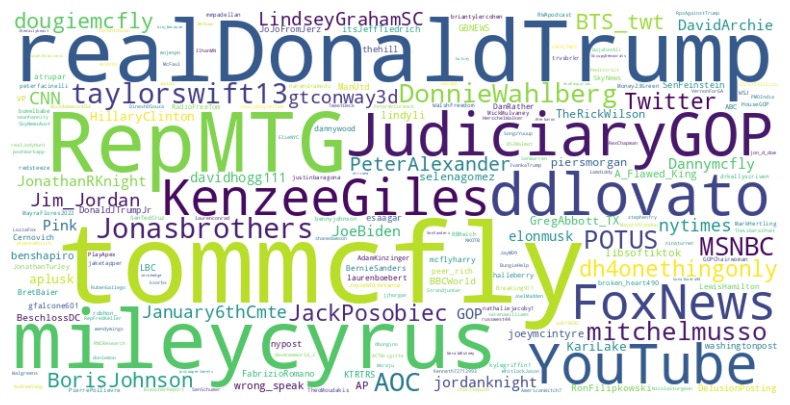

In [28]:
df = pd.read_csv(file_path+'train.csv')

mentions = []
for text in df["text"]:
    if pd.notna(text):
        mentions.extend(re.findall(r'@\w+', text))

mentions_text = " ".join(mentions)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    prefer_horizontal=1,
    normalize_plurals=False,
    collocations=False
).generate(mentions_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# URL 및 멘션 텍스트 제거 전처리

In [33]:
# TRAIN 데이터 전처리

df = pd.read_csv(file_path+"train.csv")
df["text"] = df["text"].apply(
    lambda x: re.sub(r'http[s]?://\S+', '', re.sub(r'@\w+\s*', '', str(x))) if pd.notna(x) else x)
df.to_csv(file_path+"clean_train.csv", index=False)

In [34]:
# TEST 데이터 전처리

df = pd.read_csv(file_path+"test.csv")
df["text"] = df["text"].apply(
    lambda x: re.sub(r'http[s]?://\S+', '', re.sub(r'@\w+\s*', '', str(x))) if pd.notna(x) else x)
df.to_csv(file_path+"clean_test.csv", index=False)

# 태그 전처리(선택)

In [ ]:
# TRAIN 데이터 태그 제거

df = pd.read_csv(file_path+"clean_train.csv")
df["text"] = df["text"].apply(
    lambda x: re.sub(r'#\w+\s*', '', str(x)) if pd.notna(x) else x)
df.to_csv(file_path+"clean_train_without_tag.csv", index=False)

In [35]:
# TEST 데이터 태그 제거

df = pd.read_csv(file_path+"clean_test.csv")
df["text"] = df["text"].apply(
    lambda x: re.sub(r'#\w+\s*', '', str(x)) if pd.notna(x) else x)
df.to_csv(file_path+"clean_test_without_tag.csv", index=False)